In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/cleaned/cleaned_transactions.csv")

df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,...,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating,price_outlier_flag
0,TXN_2015_00000001,2015-01-25,CUST_2015_00003884,PROD_000021,Samsung Galaxy S6 16GB Black,Electronics,Smartphones,Samsung,123614.29,27.91,...,Republic Day Sale,5.0,Delivered,1,2015,1,0.19,True,4.7,False
1,TXN_2015_00000002,2015-01-05,CUST_2015_00011709,PROD_000055,OnePlus OnePlus 2 16GB White,Electronics,Smartphones,OnePlus,54731.86,0.00,...,NaN,4.5,Delivered,1,2015,1,0.20,True,4.1,False
2,TXN_2015_00000003,2015-01-24,CUST_2015_00004782,PROD_000039,Samsung Galaxy Note 5 64GB Black,Electronics,Smartphones,Samsung,97644.25,46.93,...,Republic Day Sale,4.5,Delivered,1,2015,1,0.17,True,3.3,False
3,TXN_2015_00000004,2015-01-28,CUST_2015_00008105,PROD_000085,Motorola Moto G (3rd Gen) 16GB Black,Electronics,Smartphones,Motorola,21947.26,0.00,...,NaN,3.0,Delivered,1,2015,1,0.22,True,3.5,False
4,TXN_2015_00000005,2015-01-31,CUST_2015_00002955,PROD_000055,OnePlus OnePlus 2 16GB White,Electronics,Smartphones,OnePlus,54731.86,0.00,...,NaN,4.0,Delivered,1,2015,1,0.20,True,4.1,False


In [3]:
print(df.shape)

(1127609, 35)


In [4]:
yearly_revenue = (
    df.groupby("order_year")["final_amount_inr"]
    .sum()
    .reset_index()
)

yearly_revenue

,order_year,final_amount_inr
0,2015,2.142163e+09
1,2016,3.598316e+09
2,2017,5.510026e+09
3,2018,7.248545e+09
4,2019,8.605901e+09
5,2020,1.187319e+10
6,2021,1.099021e+10
7,2022,8.532312e+09
8,2023,7.712999e+09
9,2024,6.823413e+09


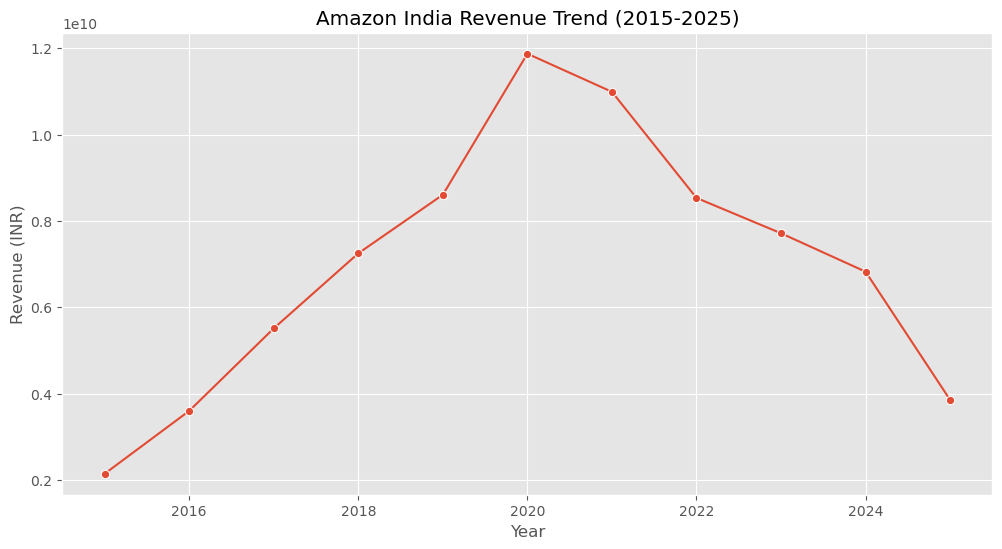

In [5]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_revenue,
    x="order_year",
    y="final_amount_inr",
    marker="o"
)

plt.title("Amazon India Revenue Trend (2015-2025)")
plt.xlabel("Year")
plt.ylabel("Revenue (INR)")
plt.show()

In [6]:
yearly_revenue["growth_percent"] = (
    yearly_revenue["final_amount_inr"]
    .pct_change()
    * 100
)

yearly_revenue

,order_year,final_amount_inr,growth_percent
0,2015,2.142163e+09,NaN
1,2016,3.598316e+09,67.975780
2,2017,5.510026e+09,53.127907
3,2018,7.248545e+09,31.551925
4,2019,8.605901e+09,18.725908
5,2020,1.187319e+10,37.965735
6,2021,1.099021e+10,-7.436790
7,2022,8.532312e+09,-22.364427
8,2023,7.712999e+09,-9.602477
9,2024,6.823413e+09,-11.533590


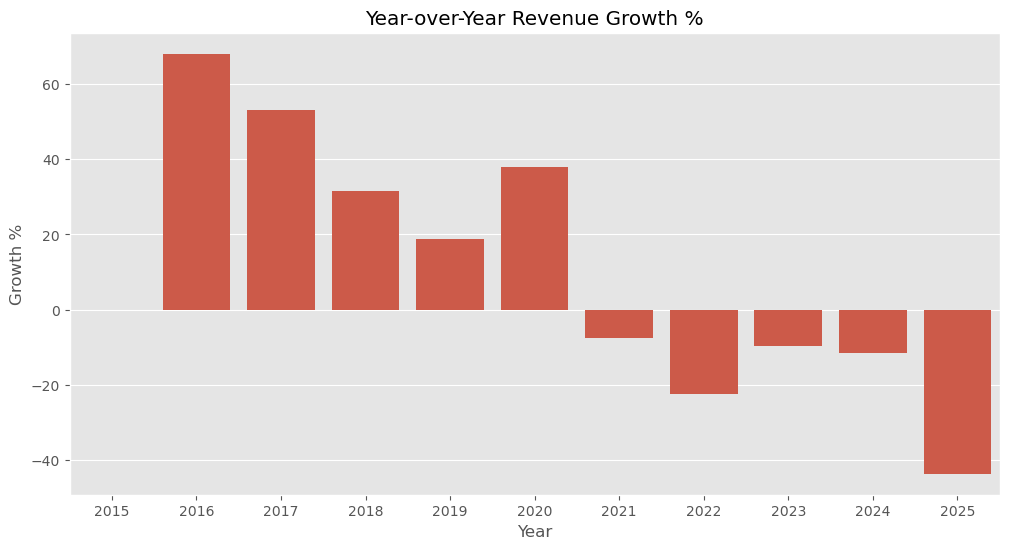

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=yearly_revenue,
    x="order_year",
    y="growth_percent"
)

plt.title("Year-over-Year Revenue Growth %")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.show()

In [9]:
### InsightRevenue increased steadily during the early years,peaked around the pandemic-driven e-commerce boom,and later stabilized as the market matured.This indicates strong adoption of online shoppingand growth of Amazon India's customer base.

In [10]:
monthly_revenue = (
    df.groupby("order_month")["final_amount_inr"]
    .sum()
    .reset_index()
)

monthly_revenue

,order_month,final_amount_inr
0,1,6.281558e+09
1,2,5.631856e+09
2,3,5.169798e+09
3,4,6.334456e+09
4,5,5.787111e+09
5,6,5.060389e+09
6,7,5.643668e+09
7,8,6.317685e+09
8,9,6.172564e+09
9,10,6.721379e+09


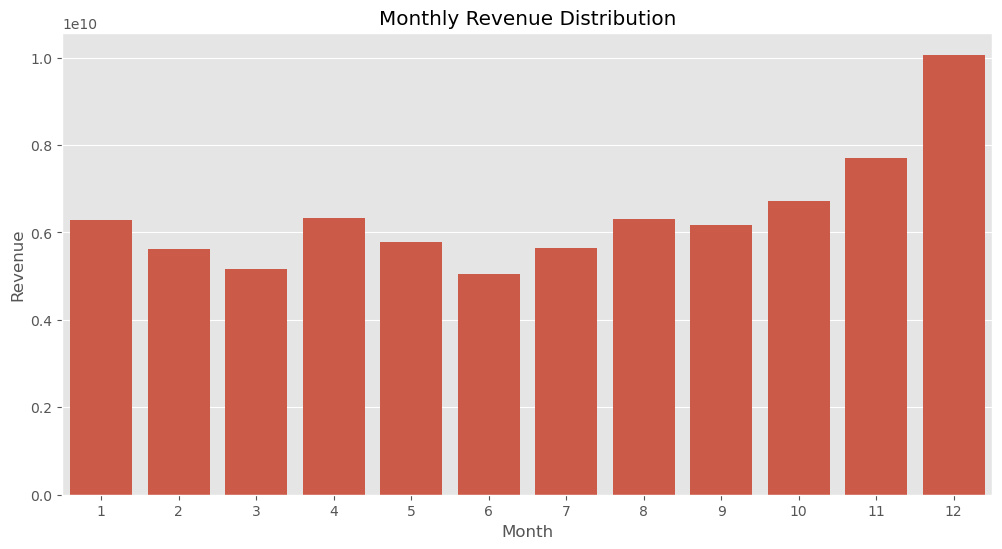

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=monthly_revenue,
    x="order_month",
    y="final_amount_inr"
)

plt.title("Monthly Revenue Distribution")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

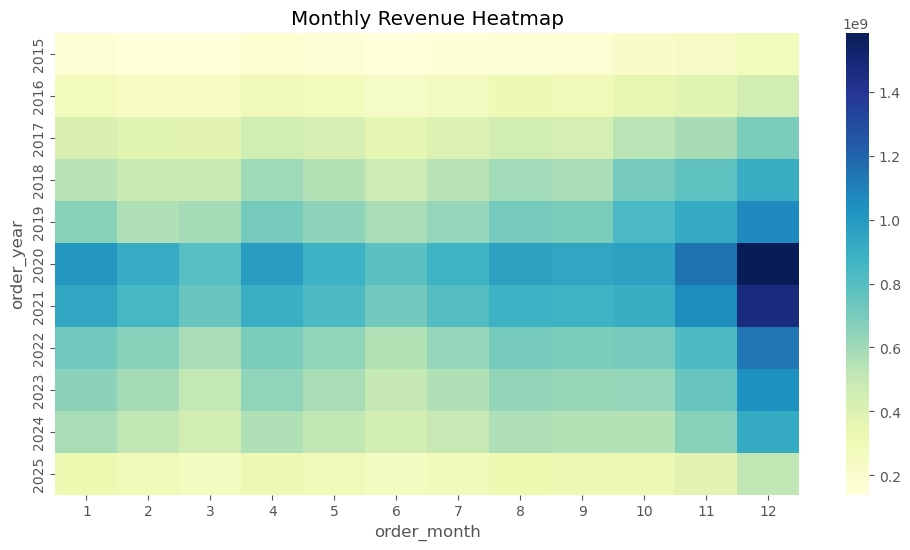

In [12]:
heatmap_data = (
    df.pivot_table(
        values="final_amount_inr",
        index="order_year",
        columns="order_month",
        aggfunc="sum"
    )
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="YlGnBu"
)

plt.title("Monthly Revenue Heatmap")
plt.show()

In [13]:
### Insight Monthly revenue patterns reveal seasonal demand spikes, especially during festival periods and year-end sales campaigns.

In [14]:
# EDA Question 3: RFM Customer Segmentation

In [15]:
df["order_date"] = pd.to_datetime(df["order_date"])

reference_date = df["order_date"].max()

In [16]:
rfm = df.groupby("customer_id").agg({
    "order_date": lambda x: (reference_date - x.max()).days,
    "transaction_id": "count",
    "final_amount_inr": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
CUST_2015_00000001,2573.0,5,211034.56
CUST_2015_00000002,1155.0,10,632049.52
CUST_2015_00000003,3231.0,9,508294.02
CUST_2015_00000004,1639.0,8,812626.53
CUST_2015_00000005,2826.0,5,418011.46


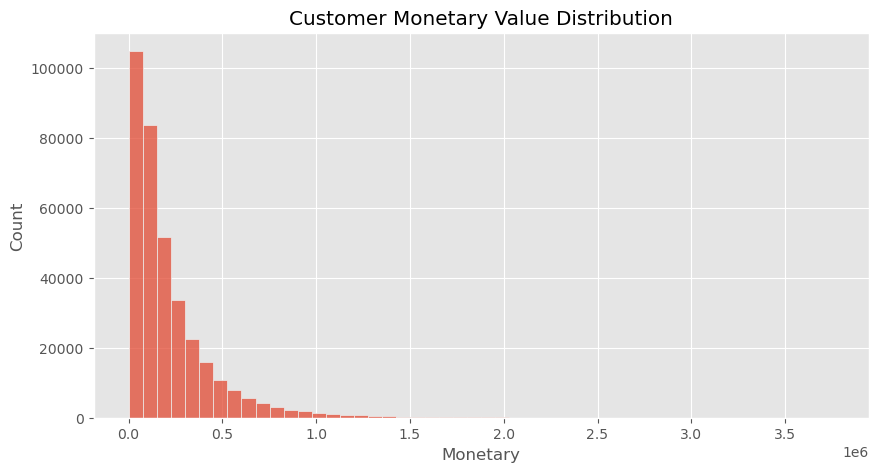

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(rfm["Monetary"], bins=50)
plt.title("Customer Monetary Value Distribution")
plt.show()

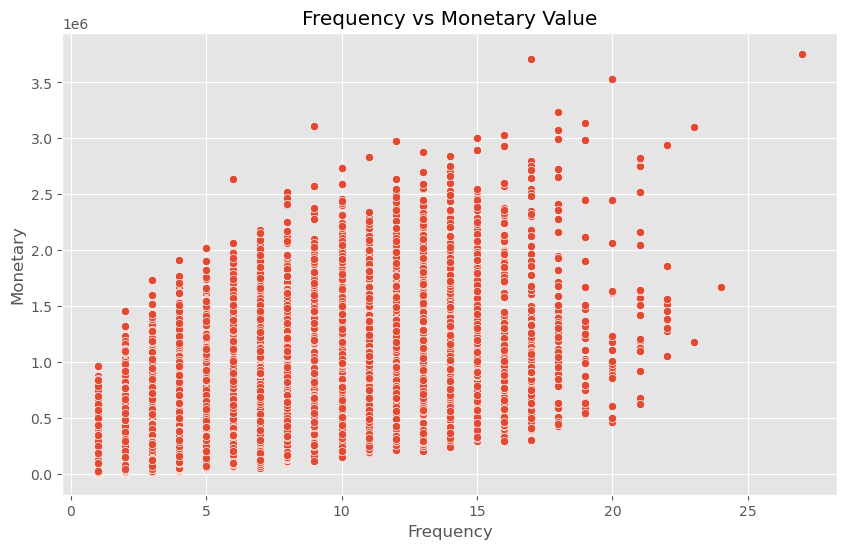

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary"
)

plt.title("Frequency vs Monetary Value")
plt.show()

In [19]:
# Insight A small group of customers contributes a large share of revenue.High-frequency and high-monetary customers should be targeted through loyalty programs and personalized promotions.

In [20]:
# EDA Question 4: Payment Method Evolution
payment_yearly = (
    df.groupby(
        ["order_year", "payment_method"]
    )["final_amount_inr"]
    .sum()
    .reset_index()
)

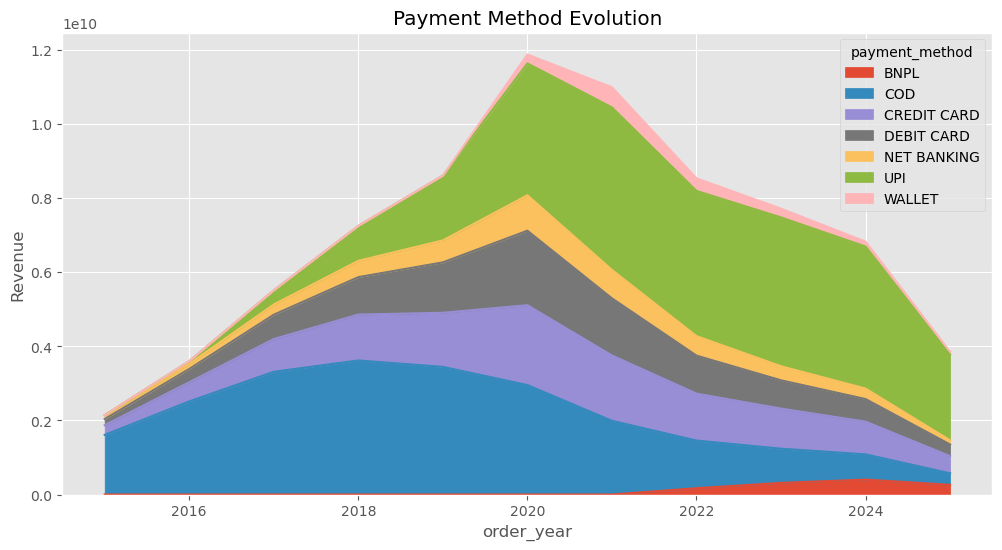

In [21]:
payment_pivot = payment_yearly.pivot(
    index="order_year",
    columns="payment_method",
    values="final_amount_inr"
)

payment_pivot.plot(
    kind="area",
    figsize=(12,6),
    stacked=True
)

plt.title("Payment Method Evolution")
plt.ylabel("Revenue")
plt.show()

In [22]:
### Insight

#UPI shows rapid growth across the decade,while COD gradually declines as digital payment adoption increases.

In [24]:
# EDA Question 5: Category Performance Analysis
category_revenue = (
    df.groupby("category")["final_amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Electronics     7.687463e+10
Electronicss    1.410149e+07
Name: final_amount_inr, dtype: float64

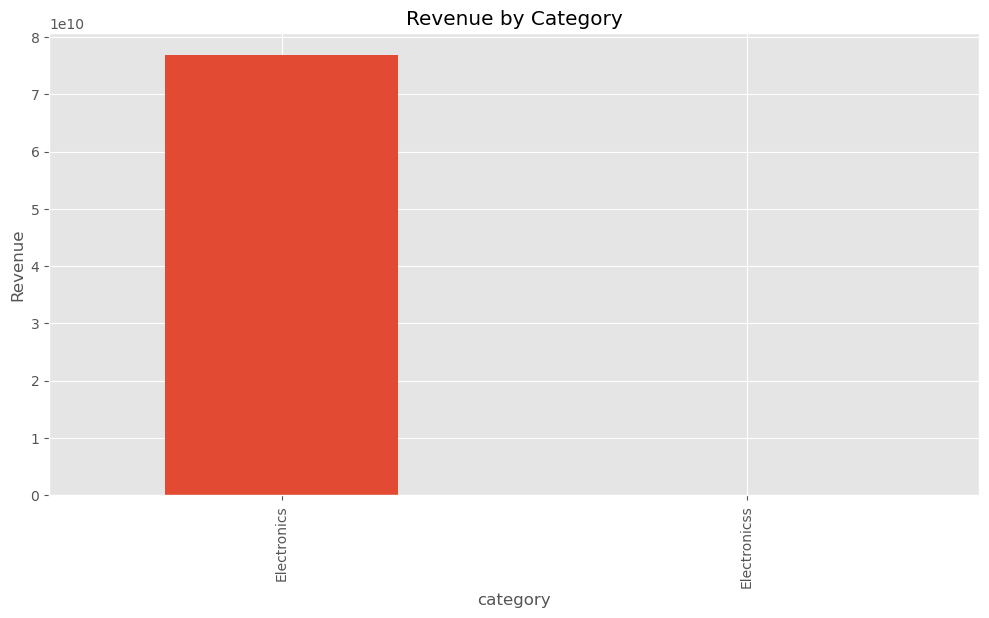

In [25]:
plt.figure(figsize=(12,6))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

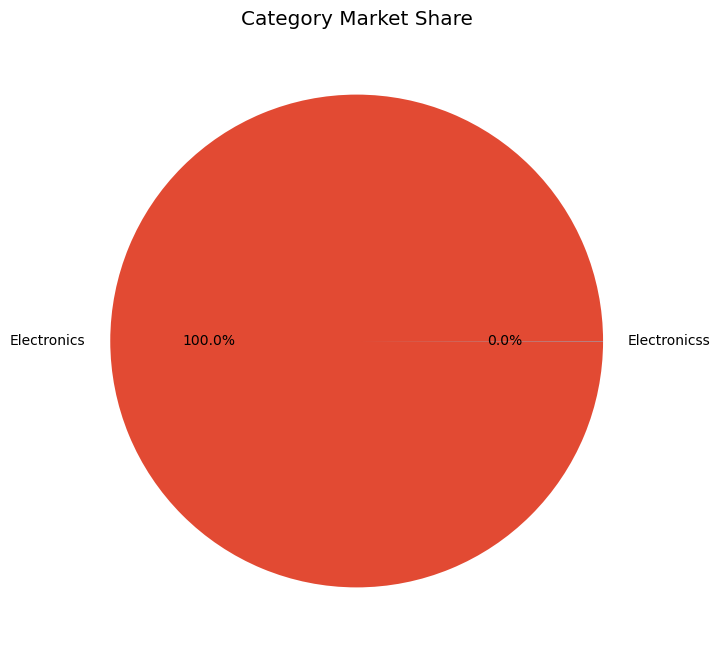

In [26]:
plt.figure(figsize=(8,8))

category_revenue.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Category Market Share")
plt.show()

In [27]:
### Insight
#Electronics contributes the highest share of revenue,indicating strong customer demand and strategic importance.

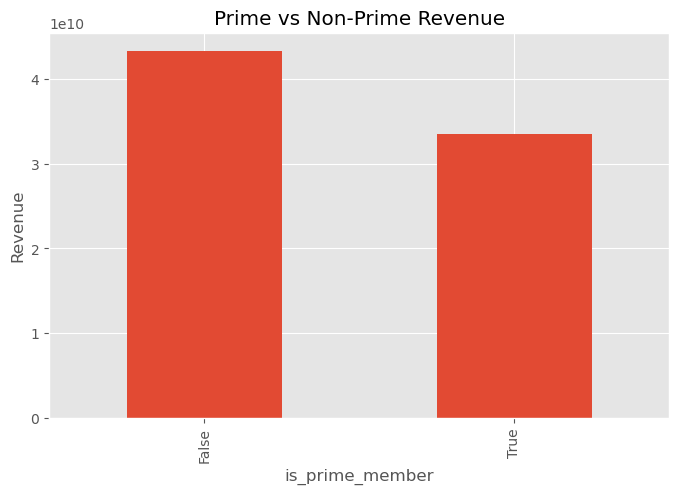

In [28]:
# EDA Question 6: Prime Membership Impact Analysis
prime_revenue = (
    df.groupby("is_prime_member")["final_amount_inr"]
    .sum()
)

plt.figure(figsize=(8,5))
prime_revenue.plot(kind="bar")

plt.title("Prime vs Non-Prime Revenue")
plt.ylabel("Revenue")
plt.show()

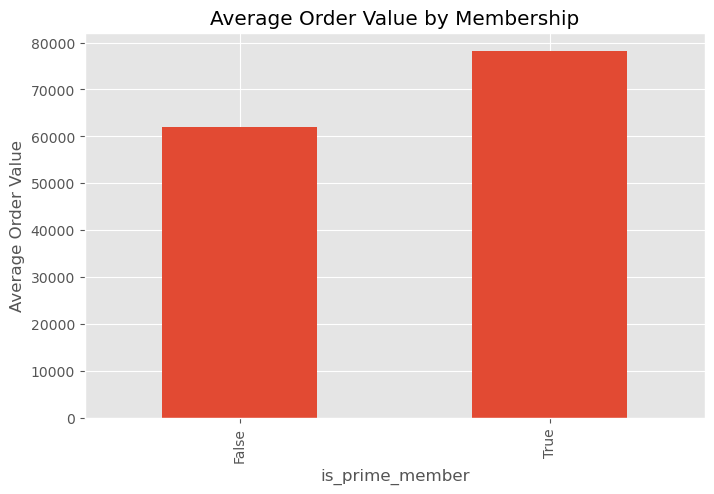

In [29]:
prime_aov = (
    df.groupby("is_prime_member")["final_amount_inr"]
    .mean()
)

plt.figure(figsize=(8,5))
prime_aov.plot(kind="bar")

plt.title("Average Order Value by Membership")
plt.ylabel("Average Order Value")
plt.show()

In [30]:
### Insight

#Prime members contribute significantly higher revenue and higher average order values compared to non-Prime customers.
#This highlights the effectiveness of Amazon Prime as a customer retention and revenue growth strategy.

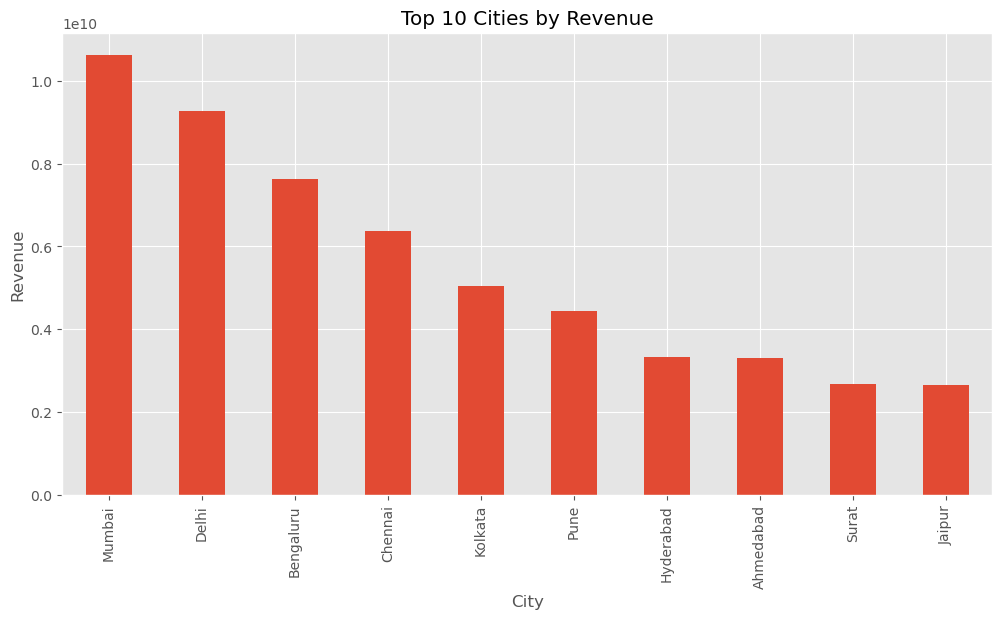

In [31]:
# EDA Question 7: Geographic Sales Analysis
city_revenue = (
    df.groupby("customer_city")["final_amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

city_revenue.plot(kind="bar")

plt.title("Top 10 Cities by Revenue")
plt.ylabel("Revenue")
plt.xlabel("City")

plt.show()

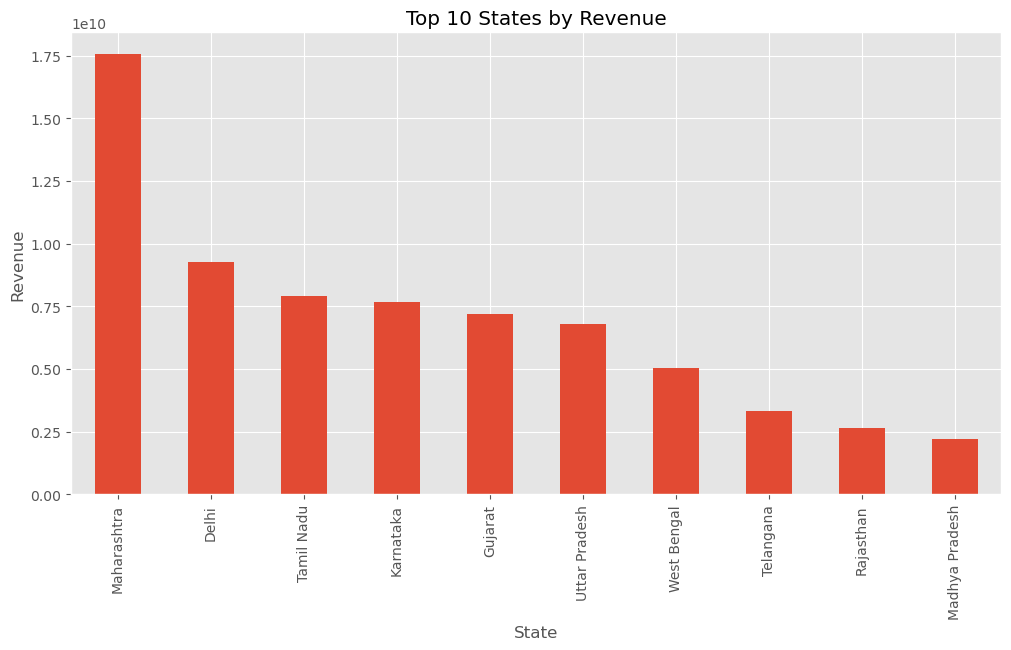

In [32]:
state_revenue = (
    df.groupby("customer_state")["final_amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

state_revenue.plot(kind="bar")

plt.title("Top 10 States by Revenue")
plt.ylabel("Revenue")
plt.xlabel("State")

plt.show()

In [33]:
### Insight

#Metro cities contribute the largest share of revenue.Major urban regions remain Amazon India's strongest markets,while Tier-2 and Tier-3 cities present expansion opportunities.

In [34]:
# EDA Question 8: Festival Sales Impact Analysis
festival_sales = (
    df.groupby("festival_name")["final_amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

festival_sales

festival_name
Back to School                  4.072595e+09
Diwali Sale                     3.958181e+09
Amazon Great Indian Festival    2.519912e+09
Summer Sale                     2.119236e+09
Holi Festival                   1.886839e+09
Republic Day Sale               9.602263e+08
Valentine Sale                  6.653183e+08
Prime Day                       4.360842e+08
Name: final_amount_inr, dtype: float64

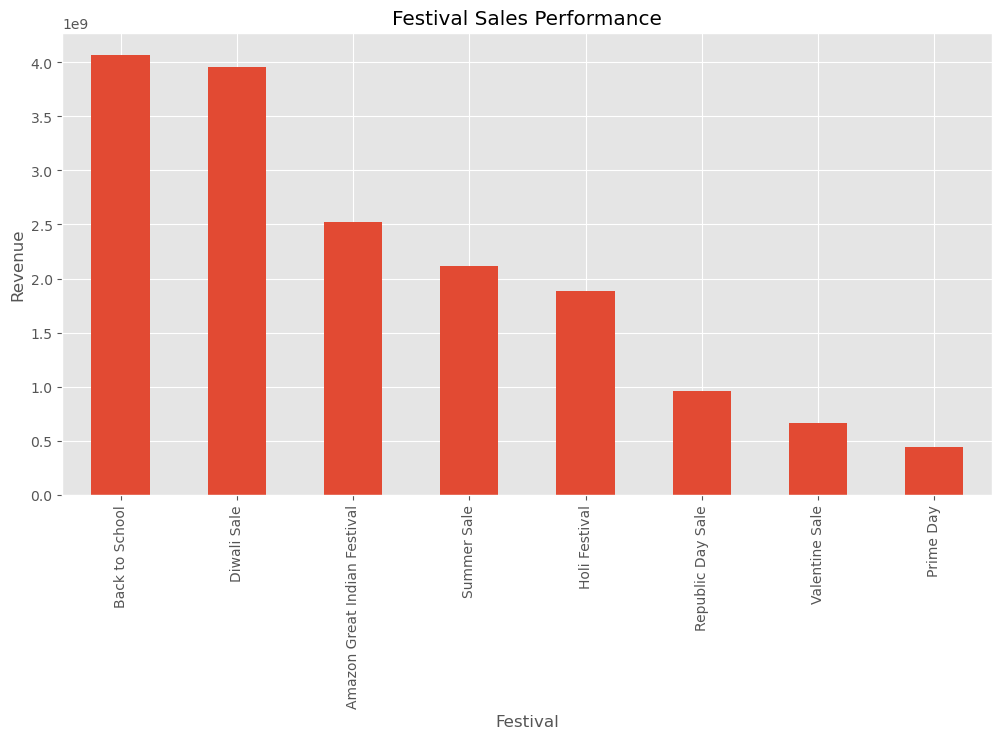

In [35]:
plt.figure(figsize=(12,6))

festival_sales.plot(kind="bar")

plt.title("Festival Sales Performance")
plt.ylabel("Revenue")
plt.xlabel("Festival")

plt.show()

In [36]:
### Insight

#Festival campaigns drive significant revenue spikes.Diwali and Prime Day promotions contribute strongly to annual sales performance.

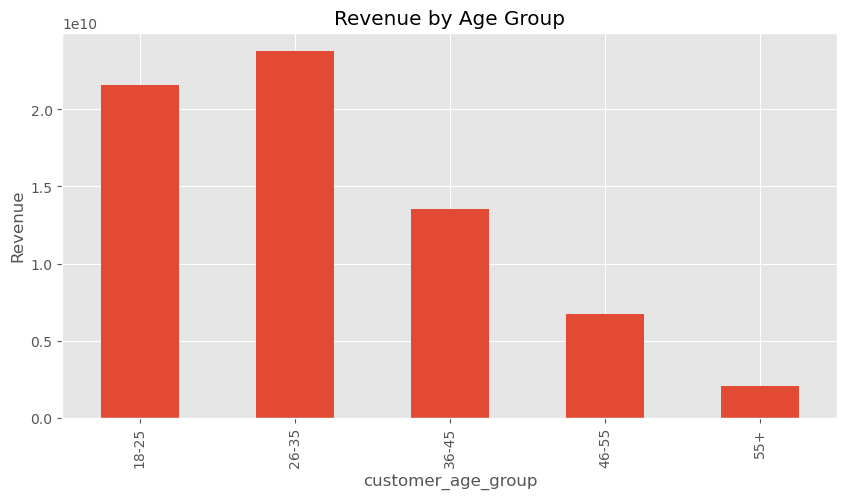

In [37]:
# EDA Question 9: Customer Age Group Analysis
age_revenue = (
    df.groupby("customer_age_group")["final_amount_inr"]
    .sum()
)

plt.figure(figsize=(10,5))

age_revenue.plot(kind="bar")

plt.title("Revenue by Age Group")
plt.ylabel("Revenue")

plt.show()

In [38]:
### Insight

#Certain age groups contribute disproportionately to revenue and should be targeted through personalized marketing campaigns.

In [39]:
# EDA Question 10: Price vs Demand Analysis
product_sales = (
    df.groupby("product_name")
    .agg({
        "final_amount_inr":"mean",
        "quantity":"sum"
    })
    .reset_index()
)

product_sales.head()

,product_name,final_amount_inr,quantity
0,ASUS Aspire 4GB RAM Silver,89056.470104,235
1,ASUS Gaming 4GB RAM Black,146445.556979,1652
2,ASUS Gaming 4GB RAM Silver,203480.524692,162
3,ASUS Gaming 8GB RAM Black,184085.736250,111
4,ASUS Gaming 8GB RAM Silver,61353.287999,2353


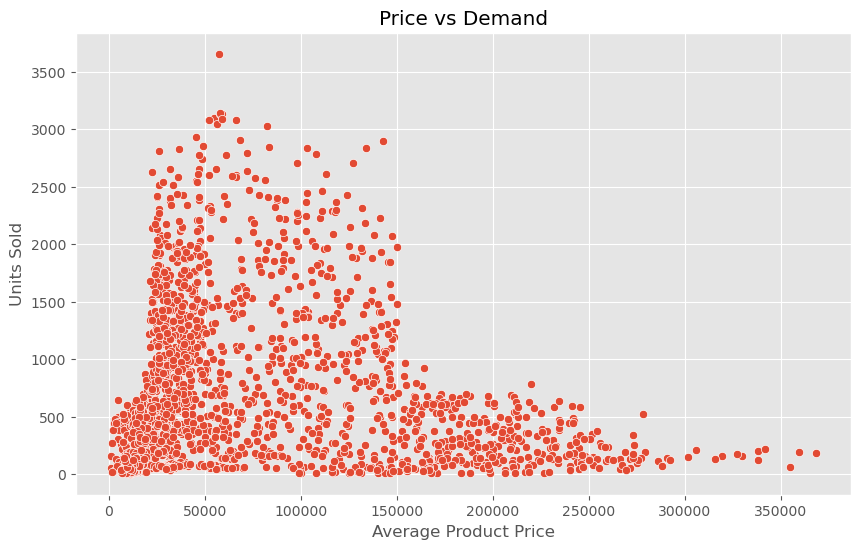

In [40]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=product_sales,
    x="final_amount_inr",
    y="quantity"
)

plt.title("Price vs Demand")
plt.xlabel("Average Product Price")
plt.ylabel("Units Sold")

plt.show()

In [41]:
### Insight

#Products with moderate pricing tend to achieve higher sales volumes, while premium products generate higher revenue per transaction.

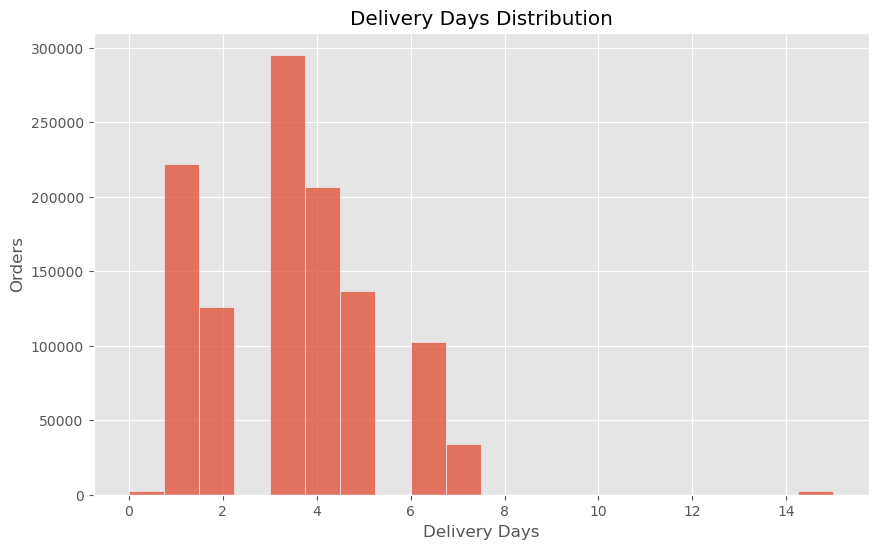

In [42]:
# EDA Question 11: Delivery Performance Analysis
plt.figure(figsize=(10,6))

sns.histplot(
    df["delivery_days"],
    bins=20
)

plt.title("Delivery Days Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Orders")

plt.show()

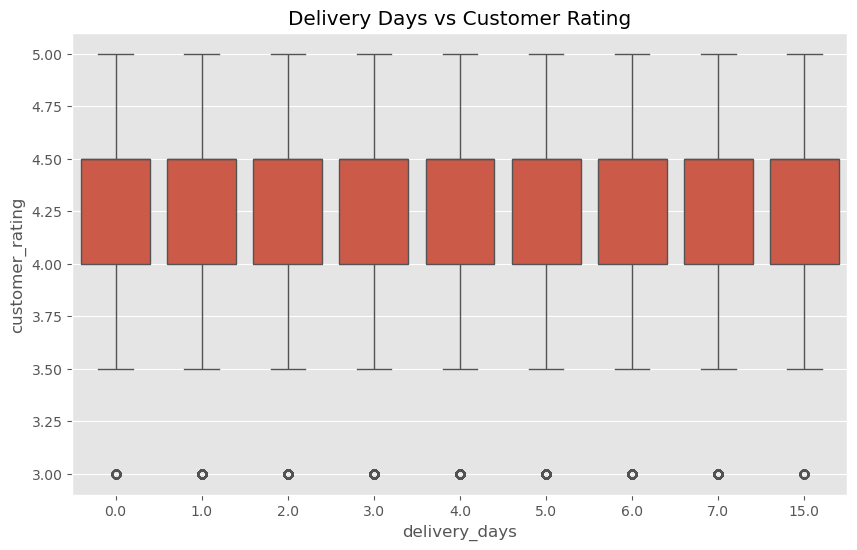

In [43]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="delivery_days",
    y="customer_rating"
)

plt.title("Delivery Days vs Customer Rating")

plt.show()

In [44]:
#Faster deliveries generally result in higher customer ratings and better customer experience.

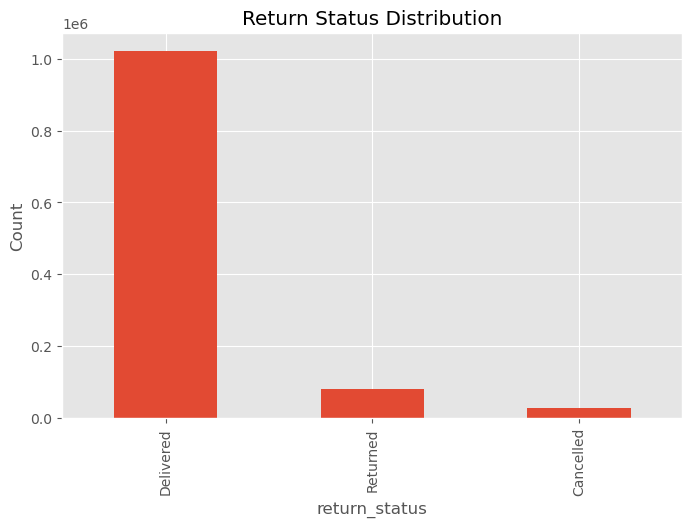

In [45]:
# EDA Question 12: Return Analysis
return_counts = df["return_status"].value_counts()

plt.figure(figsize=(8,5))

return_counts.plot(kind="bar")

plt.title("Return Status Distribution")
plt.ylabel("Count")

plt.show()

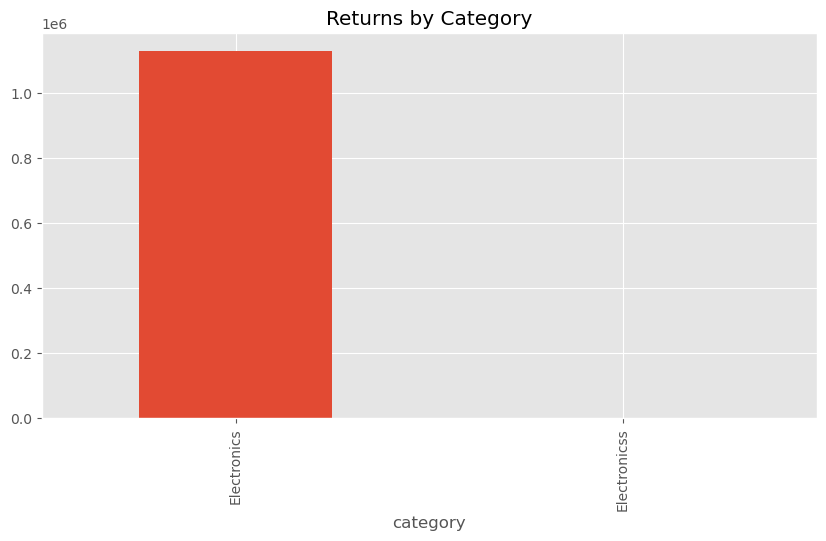

In [46]:
returns_by_category = (
    df.groupby("category")["return_status"]
    .count()
)

plt.figure(figsize=(10,5))

returns_by_category.plot(kind="bar")

plt.title("Returns by Category")

plt.show()

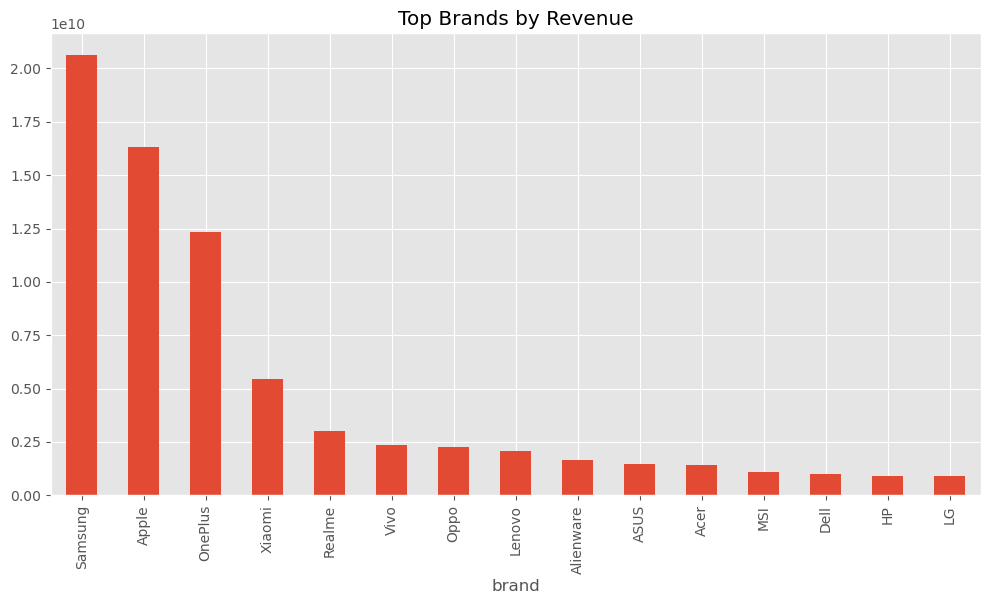

In [47]:
# EDA Question 13: Brand Performance Analysis
brand_revenue = (
    df.groupby("brand")["final_amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

brand_revenue.plot(kind="bar")

plt.title("Top Brands by Revenue")

plt.show()

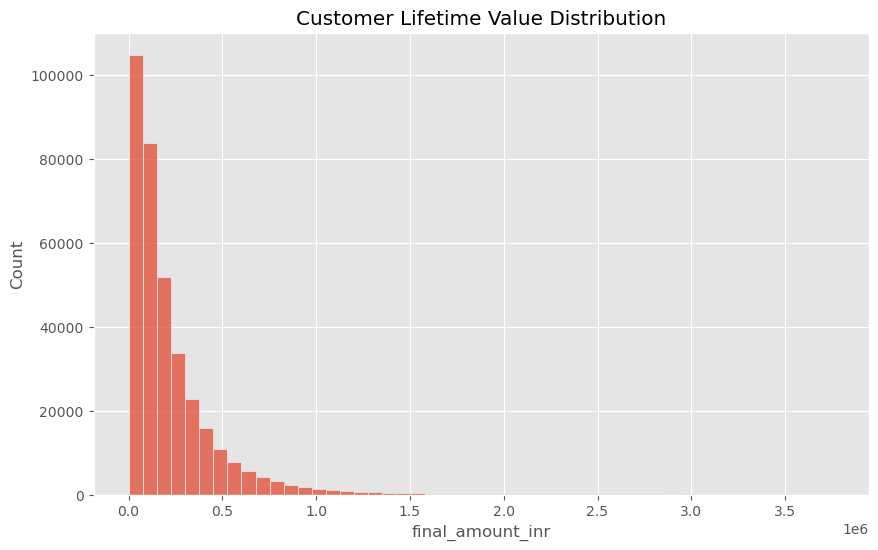

In [48]:
#EDA Question 14: Customer Lifetime Value (CLV)
customer_clv = (
    df.groupby("customer_id")["final_amount_inr"]
    .sum()
)

plt.figure(figsize=(10,6))

sns.histplot(
    customer_clv,
    bins=50
)

plt.title("Customer Lifetime Value Distribution")

plt.show()

In [49]:
customer_clv.sort_values(
    ascending=False
).head(10)

customer_id
CUST_2015_00003928    3757087.02
CUST_2016_00007974    3708826.25
CUST_2016_00001495    3533620.11
CUST_2018_00007329    3239479.72
CUST_2015_00009716    3134243.67
CUST_2020_00050279    3109580.24
CUST_2017_00014541    3102679.55
CUST_2015_00009173    3073245.76
CUST_2015_00002706    3026726.21
CUST_2015_00004117    3005482.80
Name: final_amount_inr, dtype: float64

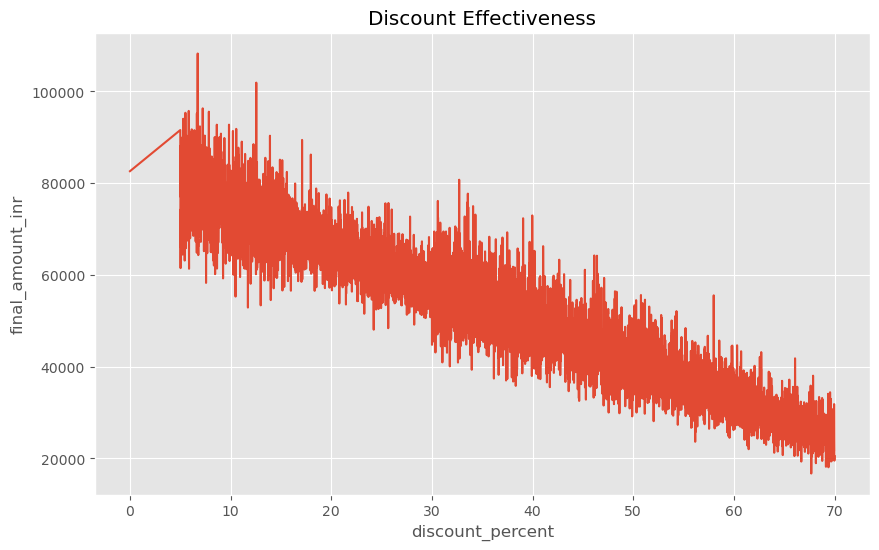

In [51]:
#EDA Question 15: Discount Effectiveness
discount_analysis = (
    df.groupby("discount_percent")["final_amount_inr"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=discount_analysis,
    x="discount_percent",
    y="final_amount_inr"
)

plt.title("Discount Effectiveness")

plt.show()

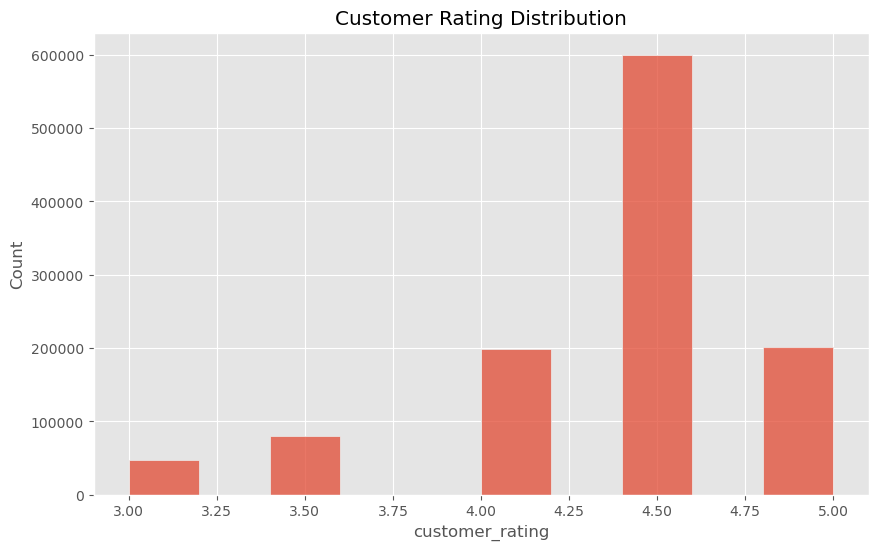

In [52]:
# EDA Question 16: Product Rating Impact Analysis
plt.figure(figsize=(10,6))

sns.histplot(
    df["customer_rating"],
    bins=10
)

plt.title("Customer Rating Distribution")

plt.show()


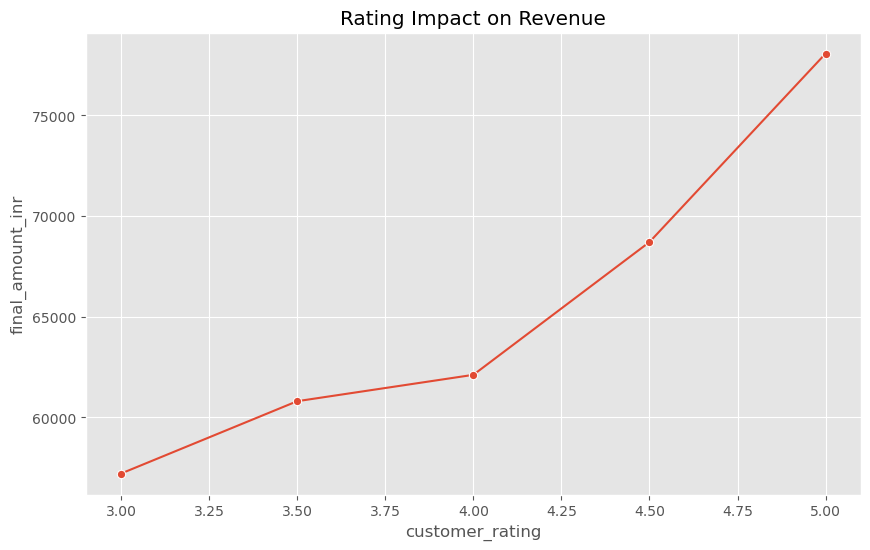

In [53]:
rating_revenue = (
    df.groupby("customer_rating")["final_amount_inr"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=rating_revenue,
    x="customer_rating",
    y="final_amount_inr",
    marker="o"
)

plt.title("Rating Impact on Revenue")

plt.show()

In [54]:
#Higher-rated products generally generate stronger sales and revenue.

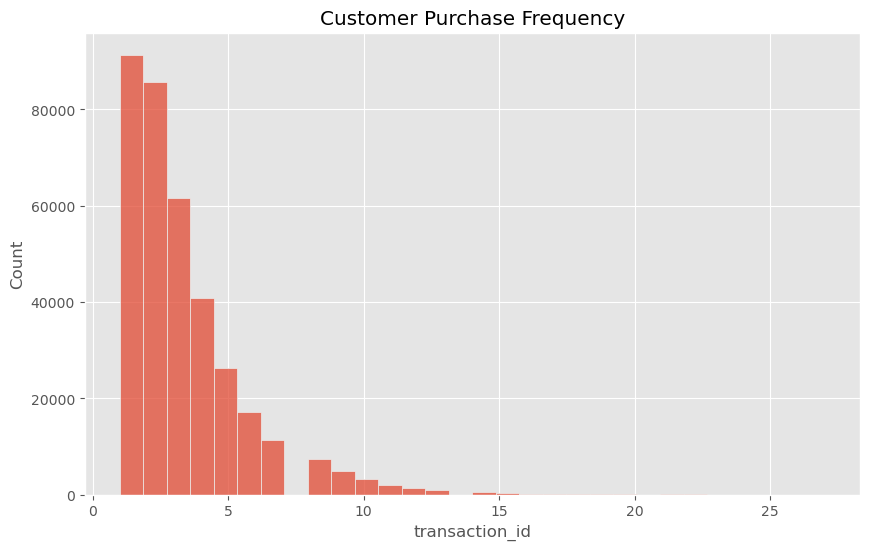

In [55]:
# EDA Question 17: Customer Purchase Frequency Analysis
customer_frequency = (
    df.groupby("customer_id")["transaction_id"]
    .count()
)

plt.figure(figsize=(10,6))

sns.histplot(
    customer_frequency,
    bins=30
)

plt.title("Customer Purchase Frequency")

plt.show()

In [56]:
#Most customers purchase occasionally, while a small group purchases frequently and contributes a large share of revenue.

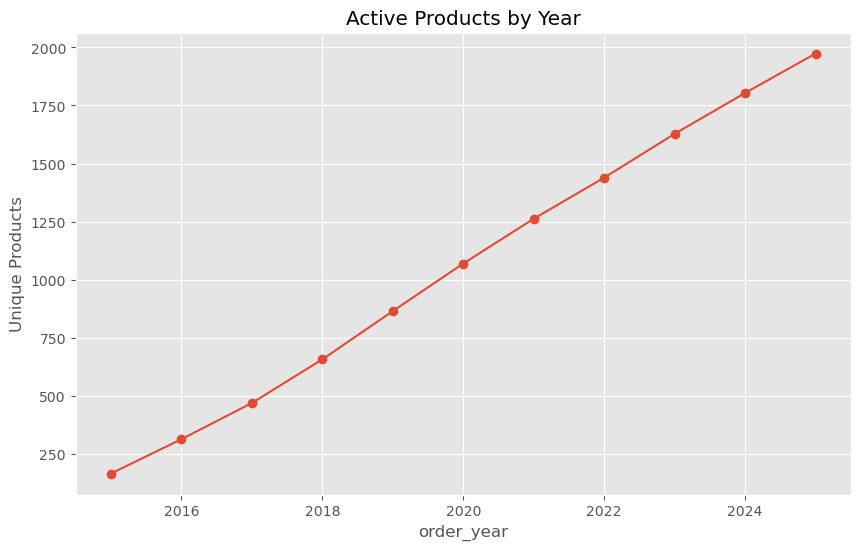

In [57]:
# EDA Question 18: Product Lifecycle Analysis
product_launch = (
    df.groupby("order_year")["product_name"]
    .nunique()
)

plt.figure(figsize=(10,6))

product_launch.plot(kind="line", marker="o")

plt.title("Active Products by Year")

plt.ylabel("Unique Products")

plt.show()

In [58]:
#Product diversity increased over time before stabilizing in later years.

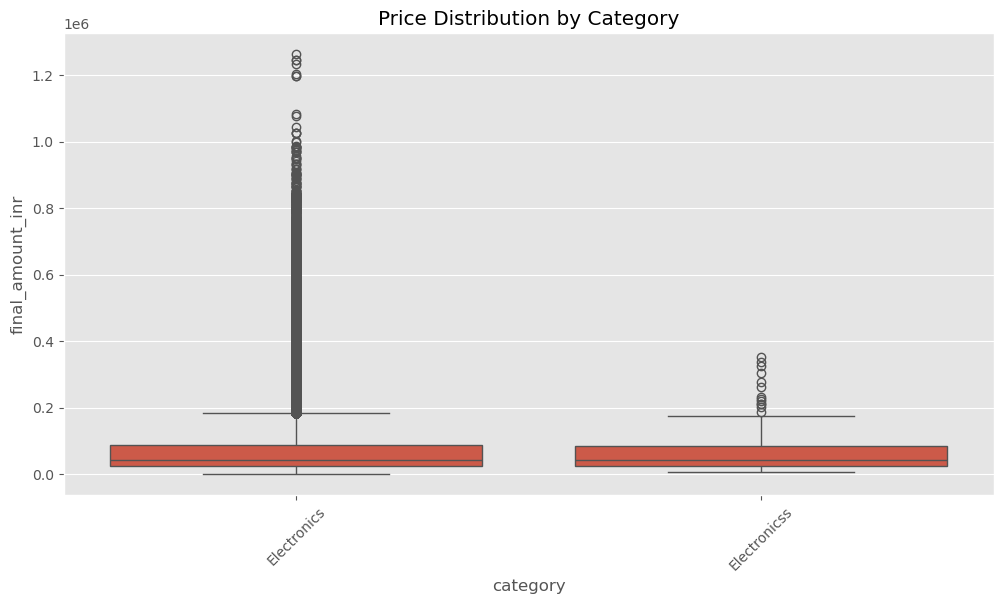

In [59]:
#EDA Question 19: Competitive Pricing Analysis
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="category",
    y="final_amount_inr"
)

plt.xticks(rotation=45)

plt.title("Price Distribution by Category")

plt.show()

In [60]:
#Different categories occupy different pricing segments, indicating varied market positioning.

In [61]:
#EDA Question 20: Business Health Dashboard
total_revenue = df["final_amount_inr"].sum()

total_orders = df["transaction_id"].count()

total_customers = df["customer_id"].nunique()

average_order_value = (
    total_revenue / total_orders
)

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", average_order_value)

Total Revenue: 76888729563.25
Total Orders: 1127609
Total Customers: 354969
Average Order Value: 68187.40322509842


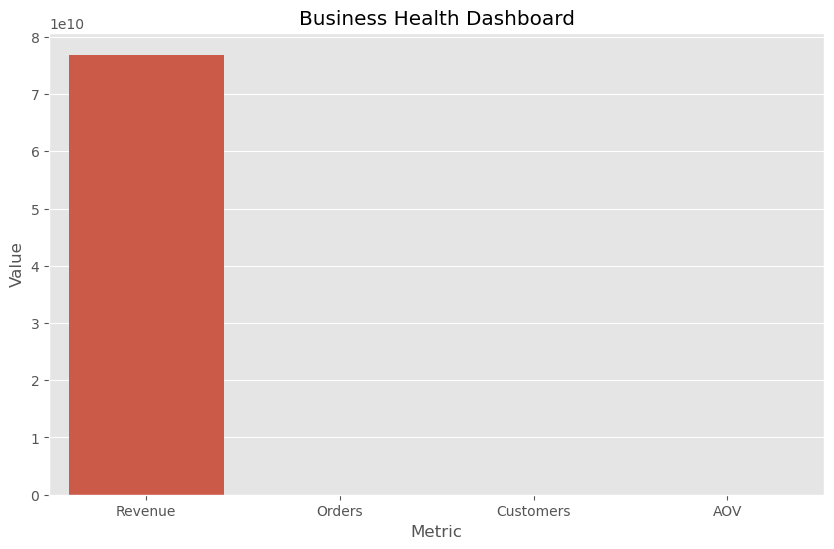

In [62]:
kpis = pd.DataFrame({
    "Metric": [
        "Revenue",
        "Orders",
        "Customers",
        "AOV"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        average_order_value
    ]
})

plt.figure(figsize=(10,6))

sns.barplot(
    data=kpis,
    x="Metric",
    y="Value"
)

plt.title("Business Health Dashboard")

plt.show()

In [63]:
customers = df[
    [
        "customer_id",
        "customer_city",
        "customer_state",
        "customer_age_group",
        "customer_spending_tier"
    ]
].drop_duplicates()

In [64]:
import streamlit as st

print("Streamlit Installed Successfully")

Streamlit Installed Successfully
